1_Ames_Housing_Dataset

¿Quién lo creó y cómo se obtuvieron los datos?
El conjunto de datos contiene información proveniente directamente de la Oficina de Tasadores (Assessors Office) de la ciudad de Ames, Iowa, utilizada para calcular los valores de tasación de propiedades residenciales vendidas en esa ciudad entre 2006 y 2010. El dataset fue introducido por el Profesor Dean De Cock en 2011 como una alternativa más moderna y rica al famoso Boston Housing Dataset de Harrison y Rubinfeld de 1978. De Cock trabajaba en la Truman State University y necesitaba un dataset más completo y realista para sus estudiantes de regresión. Los datos se obtuvieron directamente de los registros públicos de tasación fiscal del municipio, y De Cock los procesó, documentó y organizó para uso académico, publicando su trabajo en el Journal of Statistics Education.

¿De qué trata?
Describe las ventas de viviendas residenciales individuales en la ciudad de Ames, Iowa, durante un período de cinco años. Cada fila representa una propiedad vendida, con decenas de características que describen su estructura, condición, ubicación y extras.

¿Qué contiene?
El dataset contiene 2.930 instancias y un gran número de variables explicativas: 23 nominales, 23 ordinales, 14 discretas y 20 continuas, involucradas en la tasación del valor de las viviendas. Entre las variables más importantes se encuentran: superficie habitable sobre el suelo (GrLivArea), calidad general de materiales y acabados (OverallQual), año de construcción (YearBuilt), año de remodelación (YearRemodAdd), tamaño del sótano (TotalBsmtSF), número de baños completos y medios, capacidad del garaje, vecindario, tipo de acceso vial, tipo de cubierta del techo, tipo de cimentación, tipo de calefacción, existencia de piscina, de chimenea y de porche, entre muchas otras. Las 14 variables discretas típicamente cuantifican elementos dentro de la casa, como número de cocinas, habitaciones y baños, tanto en el sótano como en las plantas superiores, así como la capacidad del garaje y las fechas de construcción o remodelación.

Objetivo del modelo
El objetivo de modelado es predecir el precio de venta de una casa en función de otras características como sus atributos físicos y su ubicación. Es un problema de regresión, donde la variable objetivo es SalePrice (precio de venta en dólares). Las variables más influyentes suelen ser la calidad general (OverallQual) y la superficie habitable. Se prestan muy bien técnicas como Regresión Lineal Múltiple, Gradient Boosting (XGBoost), Random Forest y Lasso/Ridge, con especial énfasis en la ingeniería de características y el tratamiento de valores nulos, ya que varios campos como el tipo de sótano o garaje tienen NaN cuando simplemente no existe esa estructura.

Cargamos Librerías

In [1]:
# ============================================================
# LIBRERÍAS GENERALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


Carga de datos

In [2]:
# ── PASO 1: CARGA ───────────────────────────────────────────
# Usamos pandas solo para leer el CSV (el docente usa np.loadtxt
# pero este dataset tiene texto, así que pandas es necesario)
df_ames = pd.read_csv('Datasets/1_Ames_Housing_Dataset/AmesHousing.csv')

print('Filas y columnas:', df_ames.shape)
print('Primeras 3 filas:')
print(df_ames.head(3))

Filas y columnas: (2930, 82)
Primeras 3 filas:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0        0       5    2010       WD           Normal     215000  
1        0       6    2010       WD           Normal     105000  
2    12500       6    2010       WD           Normal     172000  

[3 rows x 82 columns]


Columnas con valores faltantes:
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64


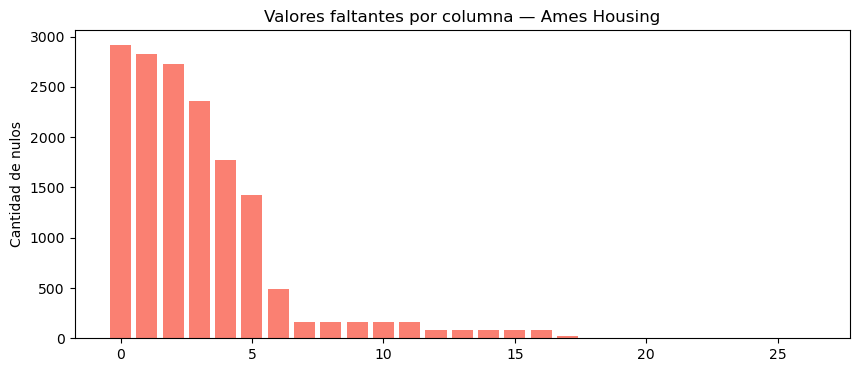

In [3]:
# ── PASO 2: DESCRIPCIÓN ─────────────────────────────────────
# ¿Cuántos valores faltantes hay?
nulos = df_ames.isnull().sum()
nulos_col = nulos[nulos > 0].sort_values(ascending=False)
print('Columnas con valores faltantes:')
print(nulos_col)

# Grafica igual que el docente
plt.figure(figsize=(10,4))
plt.bar(range(len(nulos_col)), nulos_col.values, color='salmon')
plt.title('Valores faltantes por columna — Ames Housing')
plt.ylabel('Cantidad de nulos')
plt.show()


Preaparación del Dataset

In [4]:
# ── PASO 3: LIMPIEZA ────────────────────────────────────────

# Columnas donde NaN significa 'no existe' (sin garaje, sin sótano...)
# En lugar de NaN ponemos 'None' como texto
cols_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
             'BsmtFinType2','MasVnrType']
for col in cols_none:
    if col in df_ames.columns:
        df_ames[col] = df_ames[col].fillna('None')

# Columnas numéricas donde NaN significa 0 (sin garaje = 0 autos)
cols_cero = ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1',
             'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
             'BsmtHalfBath','MasVnrArea']
for col in cols_cero:
    if col in df_ames.columns:
        df_ames[col] = df_ames[col].fillna(0)

# El resto de columnas de texto: rellenar con la moda (valor más frecuente)
for col in df_ames.select_dtypes(include='object').columns:
    df_ames[col] = df_ames[col].fillna(df_ames[col].mode()[0])

# El resto de columnas numéricas: rellenar con la mediana
for col in df_ames.select_dtypes(include='number').columns:
    df_ames[col] = df_ames[col].fillna(df_ames[col].median())

print('Nulos restantes:', df_ames.isnull().sum().sum())

Nulos restantes: 0


In [5]:
# ── PASO 4: CONVERTIR TEXTO A NÚMEROS ───────────────────────
# numpy solo trabaja con números. Las columnas de texto
# hay que convertirlas a códigos numéricos.
# Usamos pandas.Categorical que es lo más simple.
for col in df_ames.select_dtypes(include='object').columns:
    df_ames[col] = pd.Categorical(df_ames[col]).codes

print('Tipos de datos tras conversión:')
print(df_ames.dtypes.value_counts())

Tipos de datos tras conversión:
int8       43
int64      28
float64    11
Name: count, dtype: int64


In [6]:
# ── PASO 5: SEPARAR X e y ───────────────────────────────────
# Igual que el docente: X son las features, y es el target

# Columnas que no son features útiles
cols_quitar = ['SalePrice', 'Order', 'PID']
cols_features = [c for c in df_ames.columns if c not in cols_quitar]

# Convertir a arrays numpy (como hace el docente)
X = df_ames[cols_features].values.astype(float)  # matriz de features
y = df_ames['SalePrice'].values.astype(float)    # vector objetivo
m = y.size                                        # número de ejemplos

print('X shape:', X.shape)   # (filas, columnas)
print('y shape:', y.shape)   # (filas,)
print('m =', m, '(ejemplos de entrenamiento)')

X shape: (2930, 79)
y shape: (2930,)
m = 2930 (ejemplos de entrenamiento)


In [7]:
def featureNormalize(X):
    """
    Normaliza las features de X.
    Para cada columna: resta la media y divide por la desviación estándar.
    
    Retorna:
      X_norm : X normalizado (mismo tamaño que X)
      mu     : media de cada columna (se guarda para normalizar datos nuevos)
      sigma  : desviación estándar de cada columna
    """
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)   # media de cada columna
    sigma  = np.std(X, axis=0)    # desviación estándar de cada columna
    X_norm = (X - mu) / sigma     # estandarización Z-score
    return X_norm, mu, sigma

featureNormalize definida


In [8]:
# ── PASO 6: NORMALIZAR  ───────────────
X_norm, mu, sigma = featureNormalize(X)

print('Media (mu) de las primeras 5 columnas:')
print(mu[:5])
print('\nDesviación estándar (sigma) de las primeras 5 columnas:')
print(sigma[:5])
print('\nX normalizado (primeras 2 filas, primeras 5 cols):')
print(X_norm[:2, :5])

Media (mu) de las primeras 5 columnas:
[5.73873720e+01 4.96723549e+00 6.90197952e+01 1.01479218e+04
 9.95904437e-01]

Desviación estándar (sigma) de las primeras 5 columnas:
[4.26307478e+01 8.65503978e-01 2.13227822e+01 7.87867293e+03
 6.38654015e-02]

X normalizado (primeras 2 filas, primeras 5 cols):
[[-0.87700484  0.03785598  3.37574168  2.74438073  0.06412804]
 [-0.87700484 -1.11754021  0.51495179  0.18709726  0.06412804]]


X final con columna de unos: (2930, 80)
Primeros 2 ejemplos (primeras 4 cols):
[[ 1.         -0.87700484  0.03785598  3.37574168]
 [ 1.         -0.87700484 -1.11754021  0.51495179]]


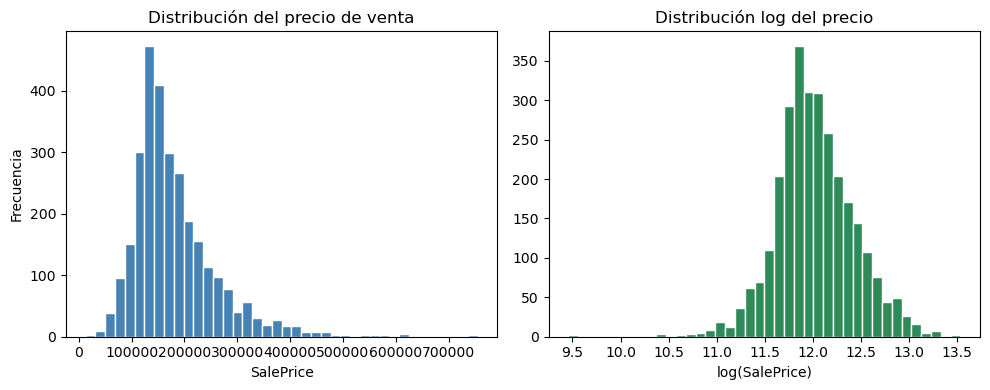

In [9]:
# ── PASO 7: AGREGAR COLUMNA DE UNOS ─────────────────────────
# Esto representa x0=1, que multiplica a theta_0 (el intercepto/bias).
# Sin esto, la recta de regresión estaría forzada a pasar por el origen.

X_ames = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print('X final con columna de unos:', X_ames.shape)
print('Primeros 2 ejemplos (primeras 4 cols):')
print(X_ames[:2, :4])
# La primera columna siempre es 1.0

# Graficar distribución del precio de venta
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.title('Distribución del precio de venta')

plt.subplot(1, 2, 2)
plt.hist(np.log(y), bins=40, color='seagreen', edgecolor='white')
plt.xlabel('log(SalePrice)')
plt.title('Distribución log del precio')
plt.tight_layout()
plt.show()